# NiCo-Wrapper Vignette — End-to-End Spatial Transcriptomics Analysis

This notebook walks you through the complete **NiCo-Wrapper** analysis pipeline, from raw `.h5ad` inputs to covariation analysis. It is designed as a self-contained vignette that you can adapt to your own data.

**Workflow overview:**

| Step | Description |
|------|-------------|
| 1. Preprocessing | Normalise and align the reference scRNA-seq data and the query spatial transcriptomis data |
| 2. Label transfer | Map reference cell-type annotations from the reference scRNAseq data onto the spatial transcriptomics data |
| 3. Niche interaction analysis | Identify spatially enriched cell-type neighbourhoods |
| 4. Covariation analysis | Discover gene programmes that co-vary across niches |

> **Tip:** Every section contains a *"What to expect"* block explaining what outputs are produced and what to inspect before moving on.

## 1. Import Required Libraries

We start by importing everything that is needed throughout the notebook.

- **`nico_wrapper`** — the package that wraps NiCo's Python API into structured, reproducible pipeline functions.
- **`pathlib.Path`** — used to build platform-independent file paths.
- **`pprint`** — handy for inspecting result dictionaries.

If any import fails, make sure the package is installed in your environment:

```bash
pip install nico-wrapper
# or, if working inside the repo:
pip install -e .
```

In [ ]:
from pathlib import Path
from pprint import pprint

# nico_wrapper pipeline entry-points
from nico_wrapper.preprocess import preprocess_nico_inputs
from nico_wrapper.transfer import (
    run_label_transfer,
    find_anchors,
    transfer_labels,
    save_transfer_result,
)
from nico_wrapper.niche import (
    run_niche_interactions,
    load_niche_result,
    export_interaction_table,
    summarize_niche_result,
)
from nico_wrapper.covariation import (
    run_covariation,
    load_covariation_result,
    export_regression_table,
)

# Configuration dataclasses (optional — only needed if you want to customise defaults)
from nico_wrapper.preprocess.config import NiCoSCTransformConfig, PearsonResidualsConfig
from nico_wrapper.transfer.config import (
    LabelTransferConfig,
    AnchorConfig,
    AnnotationConfig,
    TieStrategy,
)
from nico_wrapper.niche.config import (
    NicheInteractionConfig,
    NeighborhoodConfig,
    InteractionModelConfig,
)
from nico_wrapper.covariation.config import CovariationConfig

print("All imports successful.")

All imports successful.


## 2. Load Initial Dataset

NiCo-Wrapper accepts two `.h5ad` files as starting points:

| File | Content |
|------|---------|
| **Reference** | scRNA-seq AnnData with known cell-type labels stored in `.obs` |
| **Spatial / query** | Spatial transcriptomics AnnData with coordinates in `.obsm["spatial"]` |

Edit the paths in the cell below to point to your own data. The `spatial_key` and `ref_label_key` variables tell the pipeline where to find the coordinates and reference labels respectively.

> **Dataset requirements:**
> - Both files should share a common gene space (or a large overlap).
> - The reference `.obs` column named by `ref_label_key` must contain the cell-type annotation you want to transfer.
> - Spatial coordinates must be stored under an `.obsm` key (default: `"spatial"`).

In [ ]:
# ── Dataset paths ──────────────────────────────────────────────────────────────
# Replace these with the actual paths to your .h5ad files.

REFERENCE_H5AD  = Path("data/reference_raw.h5ad")   # reference scRNA-seq data
SPATIAL_H5AD    = Path("data/spatial_raw.h5ad")      # spatial / query data

# ── Key column names ────────────────────────────────────────────────────────────
SPATIAL_KEY   = "spatial"    # .obsm key holding XY coordinates in the spatial file
REF_LABEL_KEY = "cluster"    # .obs column holding cell-type labels in the reference data

# ── Output directories ──────────────────────────────────────────────────────────
REF_OUT_DIR     = Path("inputRef")      # preprocessed reference data outputs
SPATIAL_OUT_DIR = Path("inputQuery")    # preprocessed spatial data outputs
ANALYSIS_DIR    = Path("nico_analysis") # all downstream outputs live here

# Quick sanity check
for p in [REFERENCE_H5AD, SPATIAL_H5AD]:
    if not p.exists():
        print(f"[WARNING] File not found: {p}  — update the path before running.")
    else:
        print(f"[OK] Found: {p}")

## 3. Data Exploration

Before running the pipeline it is good practice to inspect the raw inputs and confirm that:

1. Cell counts and gene counts look reasonable.
2. The spatial coordinate key exists in `.obsm`.
3. The reference label key exists in `.obs` and contains the expected cell types.

Run the cell below to get a quick overview of both AnnData objects.

In [4]:
import anndata as ad

# Load both files for inspection (read-only)
ref_adata     = ad.read_h5ad(REFERENCE_H5AD)
spatial_adata = ad.read_h5ad(SPATIAL_H5AD)

print("=== Reference AnnData ===")
print(ref_adata)
print(f"\n  Available .obs columns : {list(ref_adata.obs.columns)}")
print(f"  Label key '{REF_LABEL_KEY}' present: {REF_LABEL_KEY in ref_adata.obs.columns}")
if REF_LABEL_KEY in ref_adata.obs.columns:
    print(f"  Cell types ({ref_adata.obs[REF_LABEL_KEY].nunique()}): "
          f"{sorted(ref_adata.obs[REF_LABEL_KEY].unique().tolist())}")

print("\n=== Spatial AnnData ===")
print(spatial_adata)
print(f"\n  Available .obsm keys   : {list(spatial_adata.obsm.keys())}")
print(f"  Spatial key '{SPATIAL_KEY}' present: {SPATIAL_KEY in spatial_adata.obsm}")

# Shared gene overlap
shared = set(ref_adata.var_names) & set(spatial_adata.var_names)
print(f"\nShared genes: {len(shared)} / ref {ref_adata.n_vars} / spatial {spatial_adata.n_vars}")

=== Reference AnnData ===
AnnData object with n_obs × n_vars = 2239 × 32287
    obs: 'cluster'

  Available .obs columns : ['cluster']
  Label key 'cluster' present: True
  Cell types (19): ['BZE', 'Blood vasc.', 'Cycling/GC B cell', 'Glial', 'Goblet', 'Lymphatic', 'MZE', 'Macrophage', 'Paneth', 'Plasma', 'Rest B', 'Stem/TA', 'Stroma', 'T cell', 'TZE', 'Tuft', 'cDC/monocyte', 'neurons/enteroendocrine', 'pDC']

=== Spatial AnnData ===
AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    obsm: 'spatial'

  Available .obsm keys   : ['spatial']
  Spatial key 'spatial' present: True

Shared genes: 240 / ref 32287 / spatial 241


## 4. Preprocessing

`preprocess_nico_inputs` takes both raw `.h5ad` files and produces three normalised outputs that every downstream step relies on:

| Output key | File | Description |
|------------|------|-------------|
| `original_counts` | `Original_counts.h5ad` | Reference data with raw counts + optionally UMAP |
| `sct_single_cell` | `sct_singleCell.h5ad` | SCTransform-normalised reference data |
| `sct_spatial` | `sct_spatial.h5ad` | SCTransform-normalised spatial transcriptomics data |

**Key parameters to tune:**

- `normalization` — Switch between `NiCoSCTransformConfig()` (default, analogous to Seurat's SCTransform) and `PearsonResidualsConfig()` for Pearson-residual normalisation.
- `gene_space` — `"shared"` retains only genes present in both datasets; `"reference_all"` keeps all reference genes.
- `leiden_resolutions` — A list of resolutions for unsupervised clustering of the spatial transcriptomics data. Inspect the clustered UMAP afterwards to decide which resolution best separates tissue regions.
- `min_cell_counts` / `min_gene_cells` — Quality-control thresholds; raise if your data is noisy.

> **What to expect:** Two output directories (`inputRef/`, `inputQuery/`) are created, each containing the processed `.h5ad` files. The function returns a dictionary of `Path` objects for downstream use. Set `overwrite=False` (default) to skip re-computation on subsequent runs.

In [ ]:
preprocess_outputs = preprocess_nico_inputs(
    REFERENCE_H5AD,
    SPATIAL_H5AD,
    # ── Output directories ───────────────────────────────────────────────────
    ref_out_dir=REF_OUT_DIR,
    spatial_out_dir=SPATIAL_OUT_DIR,
    # ── Key names ────────────────────────────────────────────────────────────
    spatial_key=SPATIAL_KEY,
    ref_label_key=REF_LABEL_KEY,
    # ── Normalisation ────────────────────────────────────────────────────────
    normalization=NiCoSCTransformConfig(),   # swap for PearsonResidualsConfig() if preferred
    # ── QC thresholds ────────────────────────────────────────────────────────
    min_cell_counts=5,
    min_gene_cells=1,
    # ── Gene space ───────────────────────────────────────────────────────────
    gene_space="shared",                     # "shared" | "reference_all"
    # ── Spatial clustering ───────────────────────────────────────────────────
    spatial_n_pcs=30,
    leiden_resolutions=[0.4, 0.5],
    # ── Misc ─────────────────────────────────────────────────────────────────
    make_reference_umap=True,
    random_state=0,
    overwrite=False,                         # set True to recompute existing files
)

print("Preprocessing outputs:")
pprint(preprocess_outputs)

## 5. Label Transfer

Cell-type labels from the reference data are propagated onto the spatial transcriptomics data in two sub-steps:

1. **Anchor discovery** (`find_anchors`) — Identifies mutual nearest-neighbour (MNN) anchor pairs between the reference data and the spatial transcriptomics data in PCA space. These anchors bridge the two modalities.
2. **Label propagation** (`transfer_labels`) — Smoothly transfers cell-type probabilities from reference anchors to every spatial cell using an iterative graph-diffusion approach. !!!CHECK RIGHT WORDING FOR THIS!!!
3. **Save** (`save_transfer_result`) — Writes the annotated spatial AnnData (with a new `.obs` column) to disk.

Or, use `run_label_transfer` to run all three steps at once (shown below as a convenience wrapper).

**Key parameters to tune:**

- `AnchorConfig.neighbors` *(default: `50`)* — Number of MNN neighbours used for anchor discovery and the spatial KNN graph. Higher values create more robust but potentially over-smoothed anchors.
- `AnnotationConfig.iterations` *(default: `3`)* — Number of iterative rounds used to propagate labels from anchored to unmapped spatial cells; more iterations increase smoothing.
- `AnnotationConfig.tie_strategy` *(default: `"majority"`)* — How to resolve ties when multiple labels have equal probability. `"majority"` uses a simple majority vote; `"weighted"` uses weighted nearest-neighbour voting.

> **What to expect:** A new file `nico_celltype_annotation.h5ad` is written to `nico_analysis/`. The transferred labels are stored in `.obs["nico_ct"]`. Inspect the label distribution to verify that the transfer looks biologically reasonable before proceeding.
>
> Additionally, `run_label_transfer` returns a `TransferOutputs` dataclass holding the following fields:
>
> | Field | Description |
> |-------|-------------|
> | `annotated_h5ad` | Path to the annotated spatial `.h5ad` with transferred labels in `.obs["nico_ct"]` |
> | `anchors_npz` | Path to the `.npz` file of MNN anchor pairs (`None` if cleanup was enabled) |
> | `output_dir` | Base output directory passed to the pipeline |
> | `annotation_dir` | Directory containing anchor/annotation intermediates |
> | `iteration_cluster_csvs` | Per-iteration cluster assignment CSVs |
> | `iteration_celltype_csvs` | Per-iteration cell-type probability CSVs |
>
> Access any field with standard dot notation, e.g. `transfer_outputs.annotated_h5ad`.

In [ ]:
# Option A — convenience wrapper (runs anchor discovery + propagation + save in one call)
transfer_outputs = run_label_transfer(
    REF_OUT_DIR,
    SPATIAL_OUT_DIR,
    output_dir=ANALYSIS_DIR,
    config=LabelTransferConfig(
        anchors=AnchorConfig(
            neighbors=50,       # number of MNN neighbours for anchor discovery and KNN graph
        ),
        annotation=AnnotationConfig(
            iterations=3,                 # label-propagation rounds
            tie_strategy="majority",      # "majority" (default) | "weighted"
        ),
        overwrite=False
    ),
)

print("Label transfer outputs:")
print(f"  Annotated h5ad : {transfer_outputs.annotated_h5ad}")
print(f"  Anchor file    : {transfer_outputs.anchors_npz}")

# ── Optional: inspect transferred label distribution ─────────────────────────
annotated = ad.read_h5ad(transfer_outputs.annotated_h5ad)
label_counts = annotated.obs["nico_ct"].value_counts()
print("\nTransferred label distribution:")
print(label_counts.to_string())

## 6. Niche Interaction Analysis

With cell-type labels on the spatial transcriptomics data, NiCo can now model the **spatial neighbourhood composition** around each cell and learn which cell-type pairs are spatially enriched.

Internally, NiCo builds a logistic-regression model per reference cell type where the predictor is the neighbourhood composition vector. The regression coefficients encode directed interaction strengths between cell types.

**Key parameters to tune:**

- `NeighborhoodConfig.radius` *(default: `0`)* — Neighbourhood mode. If `radius=0`, NiCo's Delaunay-neighbourhood mode (automatic) is used; otherwise, a positive value sets a fixed spatial radius.
- `InteractionModelConfig.c_values` *(default: `None`)* — Candidate inverse regularisation strengths for the logistic regression. If `None`, the function uses NiCo's default grid and selects the best via cross-validation; pass e.g. `(1.0,)` to fix a single value and skip CV.
- `InteractionModelConfig.n_jobs` *(default: `-1`)* — Number of parallel jobs; `-1` uses all available CPUs.

**Outputs written to disk:**

- `niche_prediction/` — Model classifier matrices (`.npz`) and a summary manifest.
- Optional plots of spatial cell-type maps.

> **What to expect:** The function returns a `NicheInteractionResult` object. Call `summarize_niche_result` to see a compact overview of the artifacts. Run `export_interaction_table` to produce a TSV of signed interaction coefficients that you can load into downstream analyses or visualisation tools.

In [ ]:
#from nico_wrapper.niche.config import NicheInteractionConfig, NeighborhoodConfig, InteractionModelConfig

niche_result = run_niche_interactions(
    ANALYSIS_DIR,
    config=NicheInteractionConfig(
        neighborhood=NeighborhoodConfig(
            radius=0,           # 0 = Delaunay neighbourhood (automatic); positive value = fixed radius
        ),
        model=InteractionModelConfig(
            # c_values is chosen automatically via cross-validation;
            # pass c_values=(1.0,) to fix a single value and skip CV
        ),
    ),
)

print("Niche interaction result summary:")
pprint(summarize_niche_result(niche_result))

# ── Export directed interaction coefficients to TSV ──────────────────────────
interaction_table_path = export_interaction_table(
    niche_result,
    cutoff=0.0,              # only keep positive (enriched) interactions
    include_self_edges=True,
)
print(f"\nInteraction table written to: {interaction_table_path}")

## 7. Covariation Analysis

Covariation analysis identifies **latent gene programmes** (factors) that co-vary with the cell-type niches discovered in the previous step. Mathematically, NiCo factorises a joint expression matrix using ridge regression to score each factor's contribution to the niche.

Two modalities are available:

| Modality | Description |
|----------|-------------|
| `"double"` | Uses both reference (single-cell) and spatial expression — recommended |
| `"single"` | Uses only spatial expression |

**Key parameters to tune:**

- `CovariationConfig.n_factors` — Number of latent factors (analogous to the number of components in NMF). Start with 3–5 and increase if the residuals remain high.
- `CovariationConfig.modality` — `"double"` or `"single"` (see table above).
- `CovariationConfig.ridge_coef_cutoff` — Minimum absolute coefficient for a gene–factor association to be exported.

**Outputs written to disk:**

- `covariation/` — Factor matrices, a state pickle (for re-loading without rerunning), and an optional TSV of ridge coefficients.

> **What to expect:** A `CovariationResult` is returned containing the path to the covariation directory. Call `export_regression_table` to get a long-format TSV with columns `factor`, `gene`, and `coefficient` that you can directly import into R or Python for downstream gene-set enrichment analysis.

In [ ]:
covariation_result = run_covariation(
    niche_result=niche_result,      # pass the in-memory result from the previous step
    ref_dir=REF_OUT_DIR,            # required for "double" modality
    spatial_dir=SPATIAL_OUT_DIR,    # required for "double" modality
    config=CovariationConfig(
        n_factors=3,                # number of latent factors; tune based on your data
        modality="double",          # "double" (recommended) | "single"
        ridge_coef_cutoff=0.0,      # export threshold for the regression table
        # ligand_receptor_db=Path("resources/NiCoLRdb.txt"),  # set explicitly if auto-discovery fails
        overwrite=False
    ),
)

print(f"Covariation directory: {covariation_result.covariation_dir}")

# ── Export ridge-regression coefficients to TSV ──────────────────────────────
regression_table_path = export_regression_table(covariation_result)
print(f"Regression table written to: {regression_table_path}")

## 8. Visualization

The cells below produce three complementary visualisations to help you interpret the results:

| Plot | What it shows |
|------|---------------|
| **Spatial cell-type map** | Where each cell type is located on the tissue slide |
| **Interaction heatmap** | Directed cell-type interaction strengths from the logistic regression |
| **Covariation factor scores** | Per-cell factor scores mapped back onto the spatial transcriptomics data |

These plots are intended as a starting point. The underlying data (interaction TSV and regression table TSV) can be loaded into any visualisation tool (e.g. Seurat, Squidpy, igraph) for publication-quality figures.

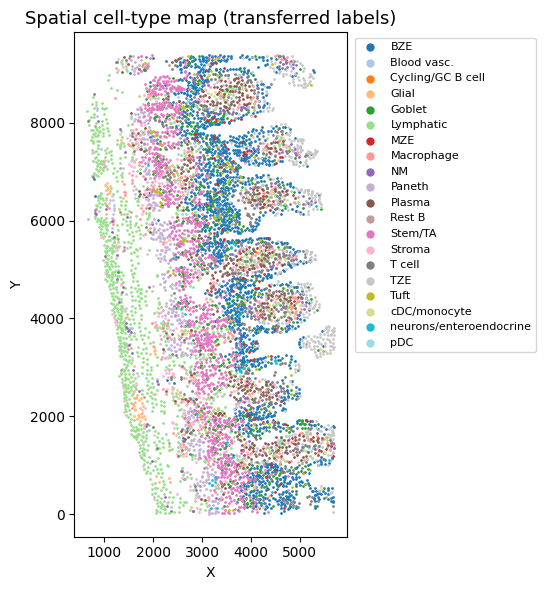

In [27]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# ── 1. Spatial cell-type map ──────────────────────────────────────────────────
annotated = ad.read_h5ad(transfer_outputs.annotated_h5ad)
coords = annotated.obsm[SPATIAL_KEY]
labels = annotated.obs["nico_ct"].astype("category")

cell_types = labels.cat.categories.tolist()
palette = dict(zip(cell_types, plt.cm.tab20.colors[:len(cell_types)]))

fig, ax = plt.subplots(figsize=(7, 6))
for ct in cell_types:
    mask = labels == ct
    ax.scatter(coords[mask, 0], coords[mask, 1], s=4, label=ct,
               color=palette[ct], linewidths=0)
ax.set_title("Spatial cell-type map (transferred labels)", fontsize=13)
ax.set_xlabel("X"); ax.set_ylabel("Y")
ax.legend(markerscale=3, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

    source_cell_type target_cell_type  source_cell_type_id  \
0                BZE              BZE                    0   
1        Blood vasc.              BZE                    1   
2  Cycling/GC B cell              BZE                    2   
3              Glial              BZE                    3   
4             Goblet              BZE                    4   

   target_cell_type_id  coefficient  coefficient_std  normalized_coefficient  \
0                    0     0.632704         0.011945                0.686398   
1                    0    -0.095083         0.015167               -0.103152   
2                    0    -0.025807         0.003428               -0.027997   
3                    0    -0.057637         0.004261               -0.062528   
4                    0     0.076748         0.019309                0.083261   

   abs_normalized_coefficient  is_self_interaction  passes_positive_cutoff  \
0                    0.686398                 True                  

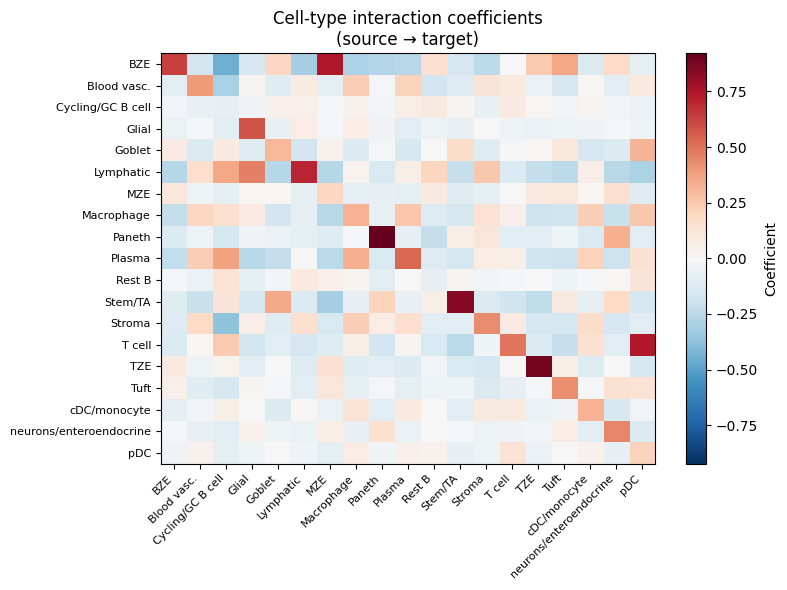

In [30]:
# ── 2. Cell-type interaction heatmap ─────────────────────────────────────────
# Load the exported interaction table
interaction_df = pd.read_csv(interaction_table_path, sep="\t")
print(interaction_df.head())

# Pivot to source × target matrix
if {"source_cell_type", "target_cell_type", "coefficient"}.issubset(interaction_df.columns):
    pivot = interaction_df.pivot_table(
        index="source_cell_type", columns="target_cell_type", values="coefficient", fill_value=0
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(pivot.values, aspect="auto",
                   cmap="RdBu_r", vmin=-pivot.values.max(), vmax=pivot.values.max())
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title("Cell-type interaction coefficients\n(source → target)", fontsize=12)
    plt.colorbar(im, ax=ax, label="Coefficient")
    plt.tight_layout()
    plt.show()
else:
    print("Column names in the interaction table:", interaction_df.columns.tolist())
    print("Update the pivot_table call to match the actual column names.")

   central_cell_type_id central_cell_type  central_factor  \
0                     0               BZE               1   
1                     0               BZE               1   
2                     0               BZE               1   
3                     0               BZE               1   
4                     0               BZE               1   

   neighbor_cell_type_id neighbor_cell_type  neighbor_factor  \
0                      0                BZE                1   
1                      0                BZE                2   
2                      0                BZE                3   
3                      4             Goblet                1   
4                      4             Goblet                2   

   neighbor_block_index  logistic_score  ridge_coefficient  \
0                     0        0.686398           0.227658   
1                     0        0.686398          -0.223628   
2                     0        0.686398           0.074017   


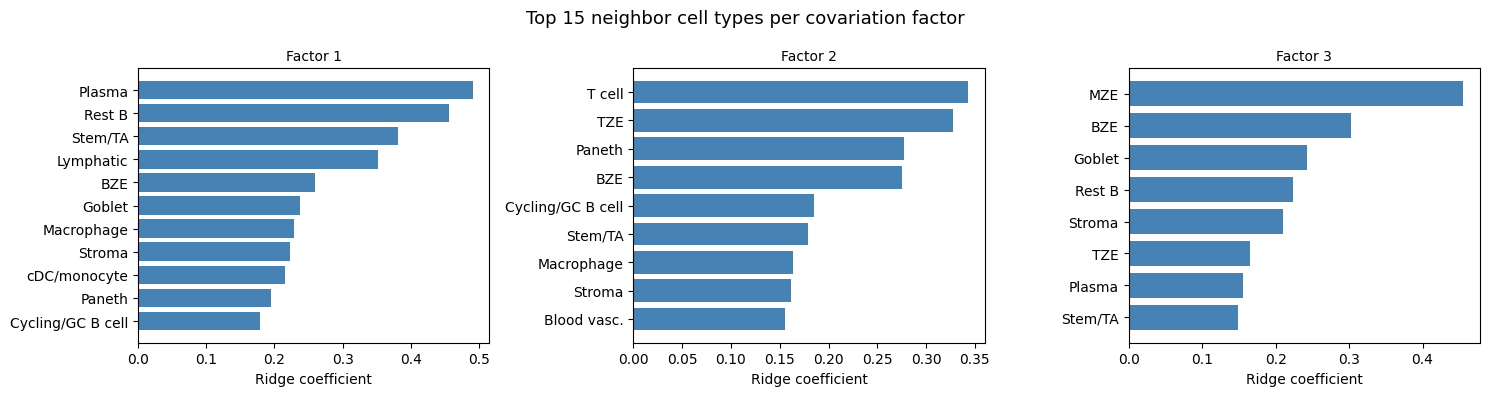

In [31]:
# ── 3. Top neighbor cell types per covariation factor ────────────────────────
regression_df = pd.read_csv(regression_table_path, sep="\t")
print(regression_df.head())

if {"central_factor", "neighbor_cell_type", "ridge_coefficient"}.issubset(regression_df.columns):
    n_top = 15
    factors = sorted(regression_df["central_factor"].unique())
    ncols = min(3, len(factors))
    nrows = int(np.ceil(len(factors) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for ax, factor in zip(axes, factors):
        sub = (regression_df[regression_df["central_factor"] == factor]
               .nlargest(n_top, "ridge_coefficient"))
        ax.barh(sub["neighbor_cell_type"], sub["ridge_coefficient"], color="steelblue")
        ax.set_title(f"Factor {factor}", fontsize=10)
        ax.set_xlabel("Ridge coefficient")
        ax.invert_yaxis()

    # Hide unused axes
    for ax in axes[len(factors):]:
        ax.set_visible(False)

    fig.suptitle(f"Top {n_top} neighbor cell types per covariation factor", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("Column names in regression table:", regression_df.columns.tolist())
    print("Update the bar-chart code to match the actual column names.")

## 9. Re-loading Results Without Rerunning

If you close this notebook and want to re-inspect results later, use the `load_*` helpers — no recomputation is needed:

```python
from nico_wrapper.niche import load_niche_result
from nico_wrapper.covariation import load_covariation_result

niche_result       = load_niche_result("nico_analysis", radius=0)
covariation_result = load_covariation_result("nico_analysis", radius=0, n_factors=3, load_state=True)
```

## 10. Next Steps

| Task | Suggestion |
|------|------------|
| Refine cell-type annotation | Adjust `LabelTransferConfig` parameters and re-run label transfer |
| Try different neighbourhood radii | Re-run `run_niche_interactions` with different `radius` values |
| Gene-set enrichment on factors | Feed the regression table genes into GSEA / ORA tools |
| Custom visualisation | Load the interaction TSV / regression TSV into Seurat, Squidpy, or igraph |

Refer to the [API documentation](api.md) for the full parameter reference of every function used in this notebook.